# Deep Learning Meets ETAS
**Francisco Plaza-Vega · STATSEI14 · 13 October 2026**

## From seismic research to one small experiment
**How can we represent seismic history so that a model can learn something useful about what follows?**

The presentation approaches this question through the published Spatial Statistics study and the aftershock work developed through Isidora Jara's thesis and the subsequent manuscript. They use different representations and targets: ETAS-derived intensity summaries and the macrozone of their maximum in the first study; aftershock sequence representations, predictive tasks and generative modelling in the later work. Their results do not measure the task in this notebook. An ETAS–GAN combination remains a research proposal; it has no empirical implementation in this tutorial or the manuscript discussed here.

Here we make the question small enough to investigate together: use **30 days of regional catalogue history** to estimate the probability of **at least one M ≥ 5 catalogue event in the next seven days**. We compare a learned sequence representation with simple baselines, then ask whether an additional channel inspired by magnitude and temporal decay helps.

The same thread runs through every step: **question → representation → model and loss → evidence**. We will build windows, train a small Keras LSTM and interpret a controlled comparison. Every learning step remains visible in Python.

**Our 23-minute guided practical:** setup (25–28), windows and splits (28–32), baselines and LSTM (32–38), add a channel (38–43), and evaluation (43–48), using minutes from the start of the session. A separate Transformer demonstration follows at 48–56, with closing discussion at 56–60. Open `transformer-demo.ipynb` for that comparison, or follow its prepared solution. You can participate by running cells or by interpreting the supplied results.

**Scope:** the frozen USGS catalogue contains revised versions downloaded in 2026. Event-time separation below does not reconstruct historical information availability. This is a retrospective teaching experiment, not an operational forecast or a prediction of shaking or risk.

Run cells in order. Use training and validation for the exercise; run the final test after fixing your configuration.

## 1. Environment and files
Use a CPU runtime. Locally, extract the course pack and open this notebook inside it. In Colab, upload the supplied **data-pack.zip** when prompted. The setup never silently downloads a changing catalogue.

If imports fail, run this in a separate cell and restart:
```python
%pip install tensorflow==2.19.1 pandas scikit-learn matplotlib
```
The full tested versions are in requirements.txt. The recorded local CPU timing is not a Colab guarantee.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_NUM_INTRAOP_THREADS"] = "2"
os.environ["TF_NUM_INTEROP_THREADS"] = "2"

from pathlib import Path
import hashlib
import json
import platform
import time
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss
import tensorflow as tf
from tensorflow import keras
from IPython.display import display

try:
    tf.config.threading.set_intra_op_parallelism_threads(2)
    tf.config.threading.set_inter_op_parallelism_threads(2)
except RuntimeError:
    print("Restart the runtime to apply reference thread settings.")
print("TensorFlow:", tf.__version__, "Keras:", keras.__version__)
print("Python:", platform.python_version(), "NumPy:", np.__version__)

TensorFlow: 2.19.1 Keras: 3.15.1
Python: 3.12.14 NumPy: 2.1.3


In [2]:
ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "config/course.json").exists():
        ROOT = candidate
        break

if ROOT is None:
    try:
        from google.colab import files
    except ImportError:
        raise FileNotFoundError("Open this notebook inside the extracted course folder.")
    print("Upload the supplied data-pack.zip (or course-pack.zip).")
    uploaded = files.upload()
    pack_names = [name for name in uploaded if name.endswith(".zip")]
    if len(pack_names) != 1:
        raise ValueError("Upload exactly one course ZIP.")
    destination = (Path.cwd() / "course-data").resolve()
    destination.mkdir(exist_ok=True)
    with zipfile.ZipFile(pack_names[0]) as archive:
        for member in archive.infolist():
            resolved = (destination / member.filename).resolve()
            if not resolved.is_relative_to(destination):
                raise ValueError("Unsafe ZIP path.")
        archive.extractall(destination)
    candidates = list(destination.rglob("config/course.json"))
    if len(candidates) != 1:
        raise ValueError("The pack must contain one config/course.json.")
    ROOT = candidates[0].parents[1]
print("Course folder:", ROOT)

Course folder: H:\Otros ordenadores\Mi PC\1_Proyectos\2026 - Statsei 14 -\statsei14-deep-learning


In [3]:
config = json.loads((ROOT / "config/course.json").read_text(encoding="utf-8-sig"))
SEED = int(config["seed"])
INPUT_MAG = float(config["input_magnitude"])
TARGET_MAG = float(config["target_magnitude"])
LOOKBACK = int(config["lookback_days"])
HORIZON = int(config["horizon_days"])
TRAIN_START = pd.Timestamp(config["train_start"], tz="UTC")
VAL_START = pd.Timestamp(config["validation_start"], tz="UTC")
TEST_START = pd.Timestamp(config["test_start"], tz="UTC")
CATALOG_END = pd.Timestamp(config["catalog_end"], tz="UTC")
ALPHA = float(config["omori_alpha"])
C_DAYS = float(config["omori_c_days"])
P = float(config["omori_p"])
feature_names = ["log_count", "max_magnitude_excess", "has_event", "log_etas_score"]
keras.utils.set_random_seed(SEED)
assert TARGET_MAG >= INPUT_MAG
assert HORIZON == 7, "This notebook uses weekly non-overlapping targets."
print("Target: at least one catalogue event M >=", TARGET_MAG)
print("History:", LOOKBACK, "days; horizon:", HORIZON, "days")
print("Evaluation mode:", config["catalog_mode"])

Target: at least one catalogue event M >= 5.0
History: 30 days; horizon: 7 days
Evaluation mode: revised_retrospective


## 2. Inspect the frozen catalogue
The download starts at M=3 for coverage diagnostics. Inputs use M≥4.5; the target includes events **exactly at M=5**. Catalogue magnitude is not uniformly Mw.

Review coverage and magnitude types before changing region. A magnitude-frequency plot alone cannot certify completeness. Parameter choices are predeclared; test metrics do not select them.

In [4]:
catalogue_path = ROOT / "data/frozen/usgs_chile_2000_2025.csv"
actual_sha256 = hashlib.sha256(catalogue_path.read_bytes()).hexdigest()
expected_sha256 = "16e9b731a5b407d75a2321d3d0d2c889542e8223a9ee4fe81efe624eb6b166d2"
assert actual_sha256 == expected_sha256, "Catalogue changed: review provenance first."
df_all = pd.read_csv(catalogue_path)
df_all["time"] = pd.to_datetime(df_all["time"], utc=True)
df_all["mag"] = pd.to_numeric(df_all["mag"], errors="coerce")
assert not df_all.id.duplicated().any()
region = config["region"]
keep = (
    df_all.mag.ge(INPUT_MAG)
    & df_all.latitude.between(region["minlatitude"], region["maxlatitude"])
    & df_all.longitude.between(region["minlongitude"], region["maxlongitude"])
    & df_all.time.lt(CATALOG_END)
)
df = df_all.loc[keep].sort_values("time").reset_index(drop=True)
assert df.time.notna().all()
print("Downloaded events:", len(df_all), "input events:", len(df))
print("SHA-256:", actual_sha256)
display(df[["time", "mag", "magType", "latitude", "longitude"]].head())

Downloaded events: 12859 input events: 2121
SHA-256: 16e9b731a5b407d75a2321d3d0d2c889542e8223a9ee4fe81efe624eb6b166d2


,time,mag,magType,latitude,longitude
0,2000-01-11 13:16:34.420000+00:00,4.5,mb,-30.747,-71.319
1,2000-01-18 17:12:18.360000+00:00,4.9,mb,-31.630,-71.451
2,2000-01-27 12:44:50.150000+00:00,4.5,mb,-33.528,-72.274
3,2000-01-30 14:08:33.750000+00:00,4.6,mb,-31.264,-69.111
4,2000-01-30 18:31:10.850000+00:00,4.8,mb,-30.616,-71.619


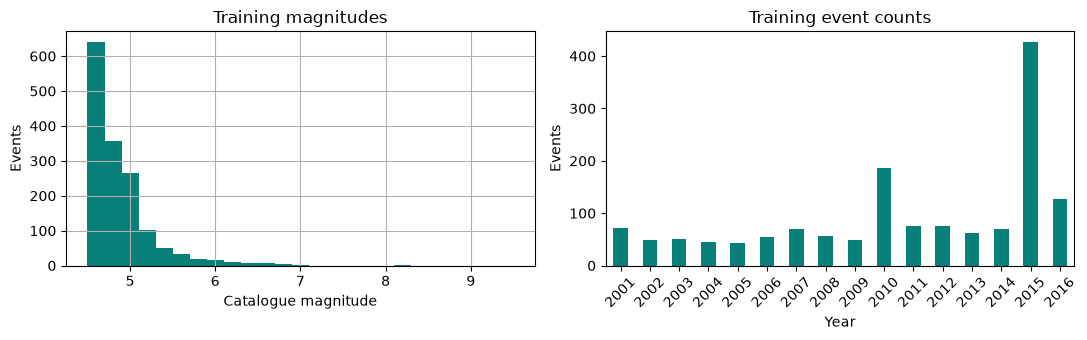

magType
mb     1032
mwr     167
mwc     106
mww     102
ml       50
mwb      24
md       19
m        11
Name: training_events, dtype: int64

In [5]:
# Inspection only; windows below are built from event records.
daily = df.set_index("time").resample("1D").agg(
    event_count=("mag", "size"), max_magnitude=("mag", "max")
)
training_catalogue = df.loc[df.time.ge(TRAIN_START) & df.time.lt(VAL_START)]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
training_catalogue.mag.hist(bins=np.arange(INPUT_MAG, 9.6, 0.2), ax=axes[0], color="#087f78")
axes[0].set(xlabel="Catalogue magnitude", ylabel="Events", title="Training magnitudes")
annual = training_catalogue.set_index("time").resample("YS").size()
annual.plot.bar(ax=axes[1], color="#087f78")
axes[1].set_xticklabels([str(x.year) for x in annual.index], rotation=45)
axes[1].set(xlabel="Year", ylabel="Events", title="Training event counts")
plt.tight_layout()
plt.show()
display(training_catalogue.magType.value_counts().rename("training_events"))
# The supplied training-diagnostics.png also compares M>=3 and M>=4.5 coverage.

## 3. One origin, one history, one target
Our first modelling choice is the representation. We summarize a regional catalogue as daily channels and predict weekly occurrence; we are not reconstructing individual events or the spatial intensity field used in the research presentation.

Each Monday at 00:00 UTC defines an example. Input: **[origin − 30 days, origin)**. Target: **[origin, origin + 7 days)**. Adjacent targets do not overlap; seismic dependence can remain.

Each day has log event count, maximum magnitude above the input threshold, and an occupancy indicator. An empty day has zero excess **and** zero occupancy. Point to one history and its target before running the cell: which details of the original catalogue have these summaries retained, and which have they discarded?

The fourth channel sums `10**(alpha*(m-M0)) * (1+age_days/c)**(-p)` at each day's end, using only past events inside the same input history. Larger and more recent events receive larger contributions. It is an **ETAS-inspired index**, with illustrative parameters, no spatial kernel and no fitted rate. We construct it now and add it to the LSTM in Section 7.

In [6]:
origins = pd.date_range(TRAIN_START, CATALOG_END, freq="W-MON", inclusive="left")
X_rows = []
metadata_rows = []

for origin in origins:
    input_start = origin - pd.Timedelta(days=LOOKBACK)
    target_end = origin + pd.Timedelta(days=HORIZON)
    history_events = df.loc[df.time.ge(input_start) & df.time.lt(origin)]
    target_events = df.loc[df.time.ge(origin) & df.time.lt(target_end) & df.mag.ge(TARGET_MAG)]
    assert history_events.empty or history_events.time.max() < origin
    daily_rows = []

    for day in pd.date_range(input_start, periods=LOOKBACK, freq="D"):
        day_end = day + pd.Timedelta(days=1)
        day_events = history_events.loc[history_events.time.ge(day) & history_events.time.lt(day_end)]
        count = len(day_events)
        max_excess = float(day_events.mag.max() - INPUT_MAG) if count else 0.0
        past_events = history_events.loc[history_events.time.lt(day_end)]
        age_days = (day_end - past_events.time).dt.total_seconds().to_numpy() / 86400
        contributions = 10 ** (ALPHA * (past_events.mag.to_numpy() - INPUT_MAG)) * (1 + age_days / C_DAYS) ** (-P)
        daily_rows.append([np.log1p(count), max_excess, float(count > 0), np.log1p(contributions.sum())])

    X_rows.append(daily_rows)
    metadata_rows.append({
        "origin": origin, "input_start": input_start, "input_end": origin,
        "target_end": target_end, "y": int(len(target_events) > 0), "count": len(target_events),
    })

X_raw = np.asarray(X_rows, dtype="float32")
windows = pd.DataFrame(metadata_rows)
y = windows.y.to_numpy(dtype="int32")
assert X_raw.shape == (len(windows), LOOKBACK, len(feature_names))
assert np.isfinite(X_raw).all()
print("X shape (weeks, days, channels):", X_raw.shape)
display(windows.head())

X shape (weeks, days, channels): (1305, 30, 4)


,origin,input_start,input_end,target_end,y,count
0,2001-01-01 00:00:00+00:00,2000-12-02 00:00:00+00:00,2001-01-01 00:00:00+00:00,2001-01-08 00:00:00+00:00,1,2
1,2001-01-08 00:00:00+00:00,2000-12-09 00:00:00+00:00,2001-01-08 00:00:00+00:00,2001-01-15 00:00:00+00:00,0,0
2,2001-01-15 00:00:00+00:00,2000-12-16 00:00:00+00:00,2001-01-15 00:00:00+00:00,2001-01-22 00:00:00+00:00,1,1
3,2001-01-22 00:00:00+00:00,2000-12-23 00:00:00+00:00,2001-01-22 00:00:00+00:00,2001-01-29 00:00:00+00:00,0,0
4,2001-01-29 00:00:00+00:00,2000-12-30 00:00:00+00:00,2001-01-29 00:00:00+00:00,2001-02-05 00:00:00+00:00,0,0


## 4. Chronological split and label purging
Past input may reach into a preceding partition. A **future target cannot cross the next boundary**. Weeks without a complete target are dropped. Class counts describe the sample; they do not determine test-driven changes.

Normalization learns its mean and scale from training inputs only. These controls concern event time, not historical reporting or revision availability.

In [7]:
windows["split"] = "purged"
train_mask = (windows.origin.ge(TRAIN_START) & windows.origin.lt(VAL_START) & windows.target_end.le(VAL_START)).to_numpy()
val_mask = (windows.origin.ge(VAL_START) & windows.origin.lt(TEST_START) & windows.target_end.le(TEST_START)).to_numpy()
test_mask = (windows.origin.ge(TEST_START) & windows.origin.lt(CATALOG_END) & windows.target_end.le(CATALOG_END)).to_numpy()
windows.loc[train_mask, "split"] = "train"
windows.loc[val_mask, "split"] = "validation"
windows.loc[test_mask, "split"] = "test"
assert not np.any(train_mask & val_mask) and not np.any(val_mask & test_mask)
assert windows.loc[train_mask, "target_end"].le(VAL_START).all()
assert windows.loc[val_mask, "target_end"].le(TEST_START).all()
assert windows.loc[test_mask, "target_end"].le(CATALOG_END).all()
assert np.unique(y[train_mask]).size == 2
summary = windows.groupby("split").agg(n=("y", "size"), positives=("y", "sum"), positive_rate=("y", "mean"))
summary["negatives"] = summary.n - summary.positives
display(summary)

,n,positives,positive_rate,negatives
split,,,,
purged,3,0,0.000000,3
test,260,54,0.207692,206
train,834,197,0.236211,637
validation,208,52,0.250000,156


In [8]:
scaler = StandardScaler()
scaler.fit(X_raw[train_mask].reshape(-1, len(feature_names)))
X_scaled = scaler.transform(X_raw.reshape(-1, len(feature_names))).reshape(X_raw.shape).astype("float32")
X_train = X_scaled[train_mask]
X_val = X_scaled[val_mask]
y_train = y[train_mask]
y_val = y[val_mask]
print("Training examples:", len(y_train), "validation:", len(y_val))
print("Training-only channel means:", scaler.mean_.round(3))

Training examples: 834 validation: 208
Training-only channel means: [0.126 0.055 0.15  0.648]


## 5. Simple baselines
Before asking whether a flexible sequence model helps, establish what simple summaries can achieve. The constant forecast uses training prevalence. Logistic regression receives mean, maximum and final-day summaries of each channel. Its scaler also uses training only.

Comparing each model with and without the score helps distinguish the contribution of this added representation from the choice of architecture. Logistic regression and LSTM do not receive identical representations: one sees summaries, the other an ordered daily sequence.

In [9]:
base_rate = y_train.mean()
base_channels = [0, 1, 2]
Z_raw = np.concatenate([X_raw.mean(axis=1), X_raw.max(axis=1), X_raw[:, -1, :]], axis=1)
Z_scaler = StandardScaler()
Z_scaler.fit(Z_raw[train_mask])
Z_scaled = Z_scaler.transform(Z_raw)
base_summary_columns = [0, 1, 2, 4, 5, 6, 8, 9, 10]
logistic_base = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
logistic_base.fit(Z_scaled[train_mask][:, base_summary_columns], y_train)
logistic_etas = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)
logistic_etas.fit(Z_scaled[train_mask], y_train)
validation_probabilities = {
    "Training frequency": np.full(len(y_val), base_rate),
    "Logistic catalogue": logistic_base.predict_proba(Z_scaled[val_mask][:, base_summary_columns])[:, 1],
    "Logistic + ETAS-inspired": logistic_etas.predict_proba(Z_scaled[val_mask])[:, 1],
}
print("Constant probability:", round(float(base_rate), 3))

Constant probability: 0.236


## 6. A small Keras LSTM
Return to the presentation's sequence model: the LSTM transforms the 30 daily inputs into a learned representation. A sigmoid output and binary cross-entropy connect that representation to our weekly occurrence question. Choosing an LSTM does not itself determine the scientific target.

**Sequential** stacks layers. **Input** describes one example's shape. **LSTM(16)** learns a sequence representation; **Dense(1, sigmoid)** produces one probability. **compile** chooses the optimizer and binary cross-entropy loss.

**fit** updates weights using training examples. An epoch passes through training data; a batch contains up to 64 examples. The callback stops after validation loss fails to improve for three epochs and restores the best weights. Validation does not update weights by backpropagation.

In [10]:
keras.backend.clear_session()
keras.utils.set_random_seed(SEED)
model_base = keras.Sequential([
    keras.Input(shape=(LOOKBACK, len(base_channels))),
    keras.layers.LSTM(config["units"]),
    keras.layers.Dense(1, activation="sigmoid"),
])
model_base.compile(
    optimizer=keras.optimizers.Adam(learning_rate=config["learning_rate"]),
    loss="binary_crossentropy",
)
model_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,297 (5.07 KB)

 Trainable params: 1,297 (5.07 KB)

 Non-trainable params: 0 (0.00 B)

Epochs: 20 CPU fit seconds: 2.14


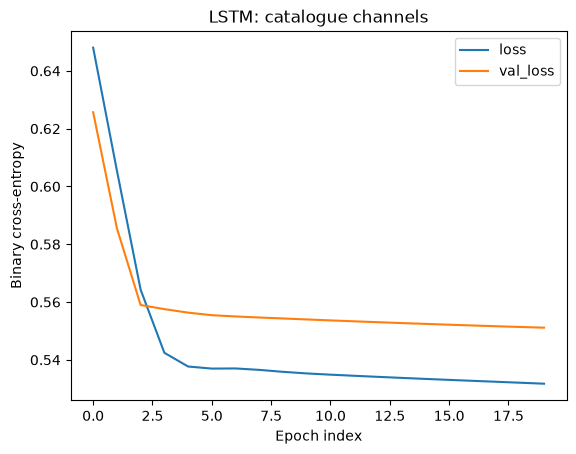

In [11]:
early_stop_base = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=config["patience"], restore_best_weights=True
)
fit_started = time.perf_counter()
history_base = model_base.fit(
    X_train[:, :, base_channels], y_train,
    validation_data=(X_val[:, :, base_channels], y_val),
    epochs=config["epochs"], batch_size=config["batch_size"],
    callbacks=[early_stop_base], shuffle=False, verbose=0,
)
base_fit_seconds = time.perf_counter() - fit_started
validation_probabilities["LSTM catalogue"] = model_base.predict(
    X_val[:, :, base_channels], verbose=0
).ravel()
print("Epochs:", len(history_base.history["loss"]), "CPU fit seconds:", round(base_fit_seconds, 2))
pd.DataFrame(history_base.history).plot(
    xlabel="Epoch index", ylabel="Binary cross-entropy", title="LSTM: catalogue channels"
)
plt.show()

## 7. Required exercise: add the ETAS-inspired channel
**Before changing the model:** write one sentence predicting whether this channel will help, and why. Its magnitude weighting and temporal decay provide a structured summary of recent activity. The existing channels may already contain enough information, or the illustrative score may be poorly suited to this target.

Add **"log_etas_score"** to `exercise_feature_names`, then rerun selection, model, fit and validation. Keep splits, seed and hyperparameters fixed. The solved notebook already contains this change.

**After the comparison:** record validation Brier score and log loss before and after. Was your expectation supported in this run? Does the channel also help logistic regression? Describe what changed in the representation and what remained fixed in the forecasting question.

Neutral or worse results are useful evidence. One seed and region cannot establish universal superiority. Both LSTMs share their architecture and protocol, but an additional channel adds some input weights. This experiment adds a feature; it does not fit ETAS or implement an ETAS–GAN model.

In [12]:
exercise_feature_names = ["log_count", "max_magnitude_excess", "has_event", "log_etas_score"]
exercise_channels = [feature_names.index(name) for name in exercise_feature_names]
exercise_model_name = "LSTM + ETAS-inspired" if "log_etas_score" in exercise_feature_names else "LSTM exercise (catalogue only)"
print("Exercise channels:", exercise_feature_names)
keras.utils.set_random_seed(SEED)
model_etas = keras.Sequential([
    keras.Input(shape=(LOOKBACK, len(exercise_channels))),
    keras.layers.LSTM(config["units"]),
    keras.layers.Dense(1, activation="sigmoid"),
])
model_etas.compile(
    optimizer=keras.optimizers.Adam(learning_rate=config["learning_rate"]),
    loss="binary_crossentropy",
)
model_etas.summary()

Exercise channels: ['log_count', 'max_magnitude_excess', 'has_event', 'log_etas_score']


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 16)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,361 (5.32 KB)

 Trainable params: 1,361 (5.32 KB)

 Non-trainable params: 0 (0.00 B)

Epochs: 20 CPU fit seconds: 2.13


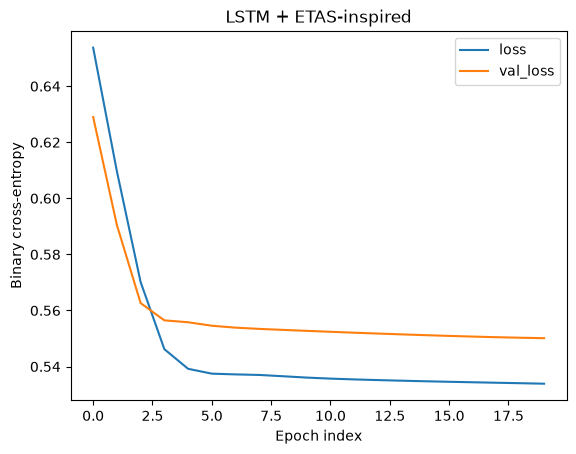

In [13]:
early_stop_etas = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=config["patience"], restore_best_weights=True
)
fit_started = time.perf_counter()
history_etas = model_etas.fit(
    X_train[:, :, exercise_channels], y_train,
    validation_data=(X_val[:, :, exercise_channels], y_val),
    epochs=config["epochs"], batch_size=config["batch_size"],
    callbacks=[early_stop_etas], shuffle=False, verbose=0,
)
etas_fit_seconds = time.perf_counter() - fit_started
validation_probabilities[exercise_model_name] = model_etas.predict(
    X_val[:, :, exercise_channels], verbose=0
).ravel()
print("Epochs:", len(history_etas.history["loss"]), "CPU fit seconds:", round(etas_fit_seconds, 2))
pd.DataFrame(history_etas.history).plot(
    xlabel="Epoch index", ylabel="Binary cross-entropy", title=exercise_model_name
)
plt.show()

In [14]:
validation_rows = []
for model_name, probability in validation_probabilities.items():
    validation_rows.append({
        "model": model_name, "split": "validation",
        "brier": brier_score_loss(y_val, probability),
        "log_loss": log_loss(y_val, probability, labels=[0, 1]),
        "n": len(y_val), "positive_rate": y_val.mean(),
    })
validation_metrics = pd.DataFrame(validation_rows)
display(validation_metrics.sort_values("brier"))
print("Total measured LSTM fit seconds:", round(base_fit_seconds + etas_fit_seconds, 2))

,model,split,brier,log_loss,n,positive_rate
4,LSTM + ETAS-inspired,validation,0.182790,0.550129,208,0.25
3,LSTM catalogue,validation,0.183109,0.551136,208,0.25
2,Logistic + ETAS-inspired,validation,0.185589,0.557167,208,0.25
1,Logistic catalogue,validation,0.186611,0.560023,208,0.25
0,Training frequency,validation,0.187690,0.562855,208,0.25


Total measured LSTM fit seconds: 4.26


### Homework extension: 14 versus 30 days
Keep the live session focused on the channel comparison. Afterwards, copy the notebook, set `LOOKBACK = 14` in the configuration cell, and rebuild windows, splits, normalization and models. Compare **validation only**. The score must use the same shorter history. Keep the seven-day target fixed. Follow the [homework guide](https://franplaza.github.io/courses/statsei14/homework.html) for further experiments and reporting prompts.

## 8. Final test evaluation
The model families and protocol are fixed above. Run the next cells **once after fixing the exercise configuration**. Do not choose new settings from test metrics and then call that test untouched. The homework continues on training and validation; this already inspected test period cannot become an untouched test for a newly selected model.

Brier score is squared probability error; log loss penalizes confidently wrong forecasts. Smaller is better. Calibration compares mean probabilities and observed frequencies; bin counts matter.

In [15]:
X_test = X_scaled[test_mask]
y_test = y[test_mask]
test_probabilities = {
    "Training frequency": np.full(len(y_test), base_rate),
    "Logistic catalogue": logistic_base.predict_proba(Z_scaled[test_mask][:, base_summary_columns])[:, 1],
    "Logistic + ETAS-inspired": logistic_etas.predict_proba(Z_scaled[test_mask])[:, 1],
    "LSTM catalogue": model_base.predict(X_test[:, :, base_channels], verbose=0).ravel(),
    exercise_model_name: model_etas.predict(X_test[:, :, exercise_channels], verbose=0).ravel(),
}
test_rows = []
for model_name, probability in test_probabilities.items():
    test_rows.append({
        "model": model_name, "split": "test",
        "brier": brier_score_loss(y_test, probability),
        "log_loss": log_loss(y_test, probability, labels=[0, 1]),
        "n": len(y_test), "positive_rate": y_test.mean(),
    })
test_metrics = pd.DataFrame(test_rows)
display(test_metrics.sort_values("brier"))

,model,split,brier,log_loss,n,positive_rate
2,Logistic + ETAS-inspired,test,0.164204,0.509854,260,0.207692
1,Logistic catalogue,test,0.164229,0.510317,260,0.207692
4,LSTM + ETAS-inspired,test,0.164718,0.511082,260,0.207692
3,LSTM catalogue,test,0.164984,0.511939,260,0.207692
0,Training frequency,test,0.165370,0.513204,260,0.207692


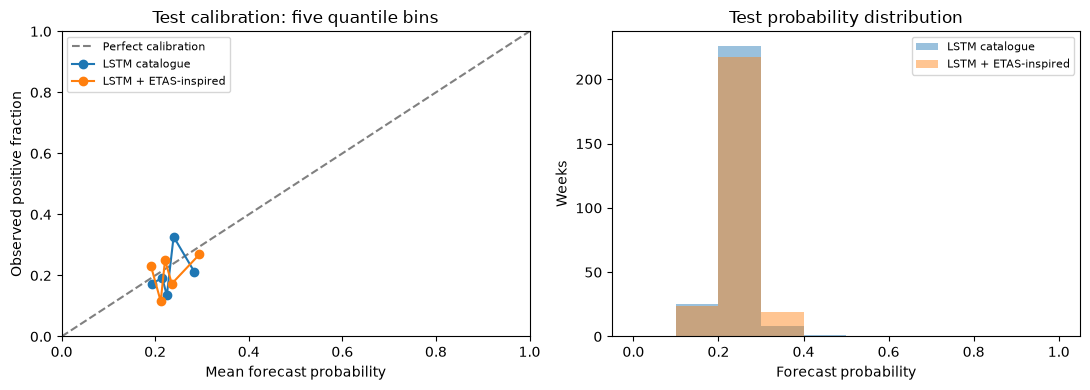

,bin,n,mean_probability,observed_fraction,model
0,"(0.159, 0.21]",52,0.193252,0.173077,LSTM catalogue
1,"(0.21, 0.22]",52,0.215046,0.192308,LSTM catalogue
2,"(0.22, 0.23]",52,0.224886,0.134615,LSTM catalogue
3,"(0.23, 0.25]",52,0.239353,0.326923,LSTM catalogue
4,"(0.25, 0.435]",52,0.283879,0.211538,LSTM catalogue
5,"(0.155, 0.207]",52,0.190963,0.230769,LSTM + ETAS-inspired
6,"(0.207, 0.216]",52,0.211771,0.115385,LSTM + ETAS-inspired
7,"(0.216, 0.227]",52,0.220992,0.250000,LSTM + ETAS-inspired
8,"(0.227, 0.251]",52,0.235562,0.173077,LSTM + ETAS-inspired
9,"(0.251, 0.382]",52,0.294662,0.269231,LSTM + ETAS-inspired


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
calibration_rows = []
for model_name in ["LSTM catalogue", exercise_model_name]:
    probability = test_probabilities[model_name]
    bins = pd.qcut(probability, q=5, duplicates="drop")
    table = pd.DataFrame({"bin": bins, "probability": probability, "y": y_test})
    table = table.groupby("bin", observed=True).agg(
        n=("y", "size"), mean_probability=("probability", "mean"), observed_fraction=("y", "mean")
    ).reset_index()
    table["model"] = model_name
    calibration_rows.append(table)
    axes[0].plot(table.mean_probability, table.observed_fraction, "o-", label=model_name)
    axes[1].hist(probability, bins=np.linspace(0, 1, 11), alpha=0.45, label=model_name)
axes[0].set(xlabel="Mean forecast probability", ylabel="Observed positive fraction",
            xlim=(0, 1), ylim=(0, 1), title="Test calibration: five quantile bins")
axes[1].set(xlabel="Forecast probability", ylabel="Weeks", title="Test probability distribution")
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()
calibration_table = pd.concat(calibration_rows, ignore_index=True)
display(calibration_table)

## 9. Save an auditable run
The solution writes `results/reference-run`; the participant notebook writes `results/participant-run`. The website reads prepared artifacts and never trains models. Saved predictions, raw features, configuration, hash and timings support inspection. Seeded runs can differ slightly across TensorFlow builds.

In [17]:
OUTPUT = ROOT / "results/reference-run"
OUTPUT.mkdir(parents=True, exist_ok=True)
metrics = pd.concat([validation_metrics, test_metrics], ignore_index=True)
metrics.to_csv(OUTPUT / "metrics.csv", index=False)
windows.to_csv(OUTPUT / "window_metadata.csv", index=False)
np.savez_compressed(OUTPUT / "features_raw.npz", X_raw=X_raw, feature_names=np.asarray(feature_names))
summary.to_csv(OUTPUT / "split_summary.csv")
prediction_frames = []
for split_name, mask, probabilities in [
    ("validation", val_mask, validation_probabilities), ("test", test_mask, test_probabilities)
]:
    for model_name, probability in probabilities.items():
        prediction_frames.append(pd.DataFrame({
            "model": model_name, "split": split_name,
            "origin": windows.loc[mask, "origin"].to_numpy(),
            "y_true": y[mask], "probability": probability,
        }))
pd.concat(prediction_frames, ignore_index=True).to_csv(OUTPUT / "predictions.csv", index=False)
pd.DataFrame(history_base.history).to_csv(OUTPUT / "history_base.csv", index=False)
pd.DataFrame(history_etas.history).to_csv(OUTPUT / "history_etas.csv", index=False)
calibration_table.to_csv(OUTPUT / "calibration.csv", index=False)
run_config = dict(config)
run_config.update({
    "lookback_days": LOOKBACK, "exercise_feature_names": exercise_feature_names,
    "catalogue_sha256": actual_sha256,
    "evaluation_scope": "Revised retrospective; historical as-of availability not verified.",
})
(OUTPUT / "config.json").write_text(json.dumps(run_config, indent=2), encoding="utf-8")
runtime = {
    "python": platform.python_version(), "tensorflow": tf.__version__, "keras": keras.__version__,
    "numpy": np.__version__, "pandas": pd.__version__, "scikit_learn": sklearn.__version__,
    "platform": platform.platform(), "processor": platform.processor(), "device": "CPU", "threads": 2,
    "lstm_base_seconds": base_fit_seconds, "lstm_etas_seconds": etas_fit_seconds,
    "total_lstm_fit_seconds": base_fit_seconds + etas_fit_seconds,
    "base_epochs": len(history_base.history["loss"]), "etas_epochs": len(history_etas.history["loss"]),
    "execution_environment": "This machine; Colab is not inferred from a local run.",
}
(OUTPUT / "runtime.json").write_text(json.dumps(runtime, indent=2), encoding="utf-8")
normalization = {"mean": scaler.mean_.tolist(), "scale": scaler.scale_.tolist(), "fitted_split": "train"}
(OUTPUT / "normalization.json").write_text(json.dumps(normalization, indent=2), encoding="utf-8")
print("Saved run:", OUTPUT)

Saved run: H:\Otros ordenadores\Mi PC\1_Proyectos\2026 - Statsei 14 -\statsei14-deep-learning\results\reference-run


## 10. Return to the scientific question
Use the evaluation block at minutes 43–48 to connect this experiment back to the research, then carry these questions into the Transformer demonstration and the final discussion at 56–60: **what did we choose to represent, what did we ask the model to learn, and what evidence did we obtain?**

1. Did the ETAS-inspired score support your initial hypothesis on validation? Did the observed difference persist in the reserved test period?
2. Did the channel help logistic regression and LSTM equally? What does that suggest about this representation, within the limits of one run?
3. What did daily regional summaries discard about locations, individual magnitudes and within-day event timing? How would the question change if the output were an intensity summary or an aftershock sequence?
4. How many weeks support each calibration bin? What could temporal dependence do to uncertainty?
5. What would change if completeness, reporting delays or magnitude types changed?

**Take-away:** deep learning offers flexible ways to connect a representation to a specified task. Scientific usefulness depends on that choice and on evidence against appropriate baselines. A more flexible model need not win this comparison.

**Limits:** revised catalogue, one region, one seed, dependent weeks, limited positive examples and illustrative parameters. Strict operational replay needs archived versions and availability times for inputs and training labels.

### The closing architecture comparison
The separate `transformer-demo.ipynb` keeps the catalogue-only representation and target fixed while comparing LSTM and attention across three seeds. Its prepared pilot results belong to a different run from this one-seed feature exercise. Discuss the measured losses and then propose an explanation that a new experiment could test. A difference in score alone cannot identify whether sample size, representation, target or training choices caused it.

### Continue after the session
The [homework guide](https://franplaza.github.io/courses/statsei14/homework.html) develops the representation and modelling questions further. Keep a copy of this fixed run, state your hypothesis before each change, and work on training and validation when choosing new settings.

### Prepared-results fallback
If training fails, stop the live training cells. Open the supplied `workshop-solved.html` and `results/reference-run/{metrics,predictions}.csv`, plus `runtime.json`. Those outputs identify a separate prepared run, not successful training on your machine.

### Optional new USGS download
Keep the frozen file for the workshop. For a separate experiment, use `python scripts/prepare_data.py --refresh` from the course source folder, or query the [USGS API](https://earthquake.usgs.gov/fdsnws/event/1/). A new region or vintage requires new provenance, an intentional checksum update and fresh checks. The current box cannot supply events outside its boundaries.

[Keras LSTM](https://keras.io/api/layers/recurrent_layers/lstm/) · [Nicolis, Plaza & Salas (2021)](https://doi.org/10.1016/j.spasta.2020.100442)

The published ETAS/LSTM/CNN study and the aftershock generative manuscript under review use different targets. Their scores are not results for this notebook. ETAS–GAN remains a proposed extension outside the empirical scope of both this practical and the manuscript.